In [7]:
import os

import torch
import torch.nn.functional as F

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from scipy import stats

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

import random

from datasets import load_from_disk
from torch.utils.data import DataLoader

from src.utils.img_encoder import ImgEncoder
from src.utils.expr_encoder import ExprEncoder
from src.utils.loss_function import contrastive_loss
from src.utils.dataset_class import Multi_Modal_Dataset

from src.utils.config import PROJECT_DIR

import optuna

# import matplotlib.pyplot as plt

In [3]:
checkpoint_path = os.path.join(PROJECT_DIR, "checkpoints", "best-epoch=68-val_loss=4.0644.ckpt")
checkpoint = torch.load(checkpoint_path, map_location="cpu")
hparams = checkpoint['hyper_parameters']

expr_encoder = ExprEncoder(
    in_dim=2000,
    hidden_dims=hparams['expr_hidden_dims'],
    out_dim=128,
    dropout_probs=hparams['expr_dropout_probs'],
    batchnorm=True # [*]
)

img_encoder = ImgEncoder(
    in_dim=2048,
    hidden_dims=hparams['img_hidden_dims'],
    out_dim=128,
    dropout_probs=hparams['img_dropout_probs'],
    batchnorm=True # [*]
)

state_dict = checkpoint['state_dict']

img_state_dict = {k.replace('img_encoder.', ''): v for k, v in state_dict.items() if k.startswith('img_encoder.')}
expr_state_dict = {k.replace('expr_encoder.', ''): v for k, v in state_dict.items() if k.startswith('expr_encoder.')}

# Load into models
img_encoder.load_state_dict(img_state_dict)
expr_encoder.load_state_dict(expr_state_dict)

img_encoder.eval()
expr_encoder.eval()

# def (img, expr, pid):
#     return img_encoder(img), expr_encoder(expr), pid
    
print("Encoder weights loaded successfully!")

Encoder weights loaded successfully!


In [4]:
arrow_dataset = load_from_disk(os.path.join(PROJECT_DIR, "data", "dataset"))
all_data = {}
with torch.no_grad():
    for k in ['train', 'valid', 'test']:
        img, expr, pid = next(iter(DataLoader(
            Multi_Modal_Dataset(arrow_dataset[k], k_patches="all"),
            batch_size=len(arrow_dataset[k])
        )))
        all_data[k+'_img'] = img
        all_data[k+'_expr'] = expr
        all_data[k+'_img_emb'] = img_encoder(img)
        all_data[k+'_expr_emb'] = expr_encoder(expr)
        all_data[k+'_pid'] = [p[:12] for p in pid]

for x in ['_img', '_expr']:
    for y in ['', '_emb']:
        all_data['dev'+x+y] = torch.cat((all_data['train'+x+y], all_data['valid'+x+y]), dim=0)
all_data['dev_pid'] = all_data['train_pid'] + all_data['valid_pid']

sims = F.cosine_similarity(
    all_data['test_img_emb'].unsqueeze(1), 
    all_data['dev_img_emb'].unsqueeze(0), 
    dim=2
)

# sanity check!
for i in range(all_data['test_img_emb'].shape[0]):
    for j in range(all_data['dev_img_emb'].shape[0]):
        assert abs(sims[i, j].item() - torch.matmul(
            F.normalize(all_data['test_img_emb'][i].unsqueeze(0), dim=1), 
            F.normalize(all_data['dev_img_emb'][j].unsqueeze(0), dim=1).T
        ).item()) < 1e-6

sorted_sims = torch.argsort(sims, dim=1, descending=True)

pid_mapping = {
    all_data['test_pid'][i]: [all_data['dev_pid'][j] for j in row.tolist()]
    for i, row in enumerate(sorted_sims)
}

In [5]:
clin_df = pd.read_csv(os.path.join(PROJECT_DIR, "data", "data_clinical_patient.txt"), sep='\t', header=None)
clin_df.columns = clin_df.iloc[4].values
clin_df = clin_df.iloc[5:].reset_index(drop=True)
clin_df['SUBTYPE'] = clin_df['SUBTYPE'].str.replace('BRCA_', '', regex=False)
pid2subtype = clin_df.set_index('PATIENT_ID')['SUBTYPE'].to_dict()

def zero_shot_subtype_classification(K):
    
    knn_subtypes = { 
        k: [pid2subtype[k]] + [pid2subtype[p] for p in v if pd.notna(pid2subtype[p])]
        for k, v in pid_mapping.items()
    }
    knn_subtypes = pd.DataFrame(knn_subtypes)
    knn_subtypes = knn_subtypes.dropna(axis=1, how='any')
    knn_subtypes = knn_subtypes.iloc[:(K+1)]

    def get_strict_majority(col):
        # 1. Get the frequency counts
        counts = col.value_counts()
        
        assert not counts.empty
        
        # 2. If there's only one unique value, it's the majority
        if len(counts) == 1:
            return counts.index[0]
        
        # 3. Compare the count of the 1st most frequent to the 2nd
        # If the 1st frequency is strictly greater than the 2nd, we have a winner
        if counts.iloc[0] > counts.iloc[1]:
            return counts.index[0]
        
        # 4. Otherwise, it's a tie (e.g., [a, b, c, b, a, c] or [a, a, b, b])
        return 'Unclassified'

    vote_subtypes = pd.concat(
        [knn_subtypes.iloc[:1], knn_subtypes.iloc[1:].agg([get_strict_majority])], 
        axis=0
    ).reset_index(drop=True)

    y_true = vote_subtypes.iloc[0].tolist()
    y_pred = vote_subtypes.iloc[1].tolist()
    
    return y_true, y_pred

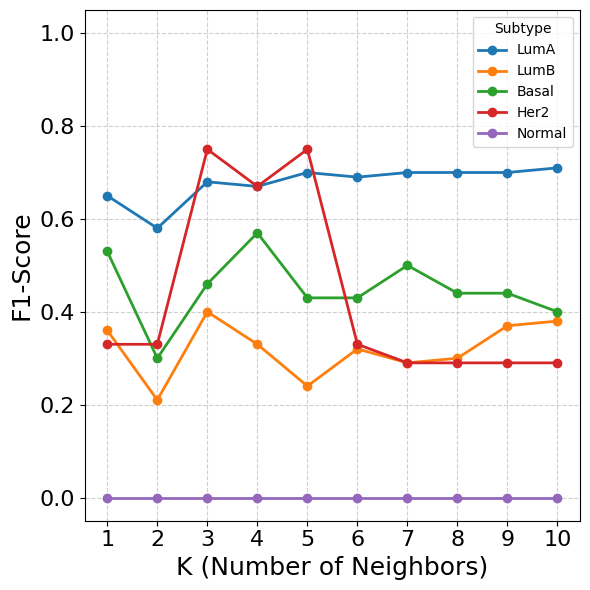

In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt

classes = ['LumA', 'LumB', 'Basal', 'Her2', 'Normal']
results = []

for k in range(1, 11):

    y_true, y_pred = zero_shot_subtype_classification(k)
    classes = ['LumA', 'LumB', 'Basal', 'Her2', 'Normal', 'Unclassified']
    assert set(y_true+y_pred+['Unclassified']) == set(classes)

    # 1. Get the string of classification_report
    report_str = classification_report(y_true=y_true, y_pred=y_pred, labels = classes, zero_division=0)
    
    # 2. Extract f1-scores for each class using regex
    # It looks for the class name and grabs the third decimal number (f1)
    k_f1s = {'K': k}
    for cls in classes:
        pattern = rf"{cls}\s+[\d.]+\s+[\d.]+\s+([\d.]+)"
        match = re.search(pattern, report_str)
        k_f1s[cls] = float(match.group(1)) if match else 0.0
        
    results.append(k_f1s)

# 3. Convert results to a DataFrame for easy plotting
df_plot = pd.DataFrame(results).set_index('K')

classes.remove('Unclassified')
df_plot = df_plot.drop('Unclassified', axis=1)

# 4. Generate the plot
plt.figure(figsize=(6, 6))
for cls in classes:
    plt.plot(df_plot.index, df_plot[cls], marker='o', label=cls, linewidth=2)

plt.tick_params(axis='both', labelsize=16)
plt.xlabel('K (Number of Neighbors)', fontsize=18)
plt.ylabel('F1-Score', fontsize=18)
plt.xticks(range(1, 11))
plt.ylim(-0.05, 1.05) # Keeps the scale consistent 0 to 1
plt.legend(title="Subtype")#, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("zeroshot_F1_scores.pdf", format='pdf', bbox_inches='tight')
plt.show()

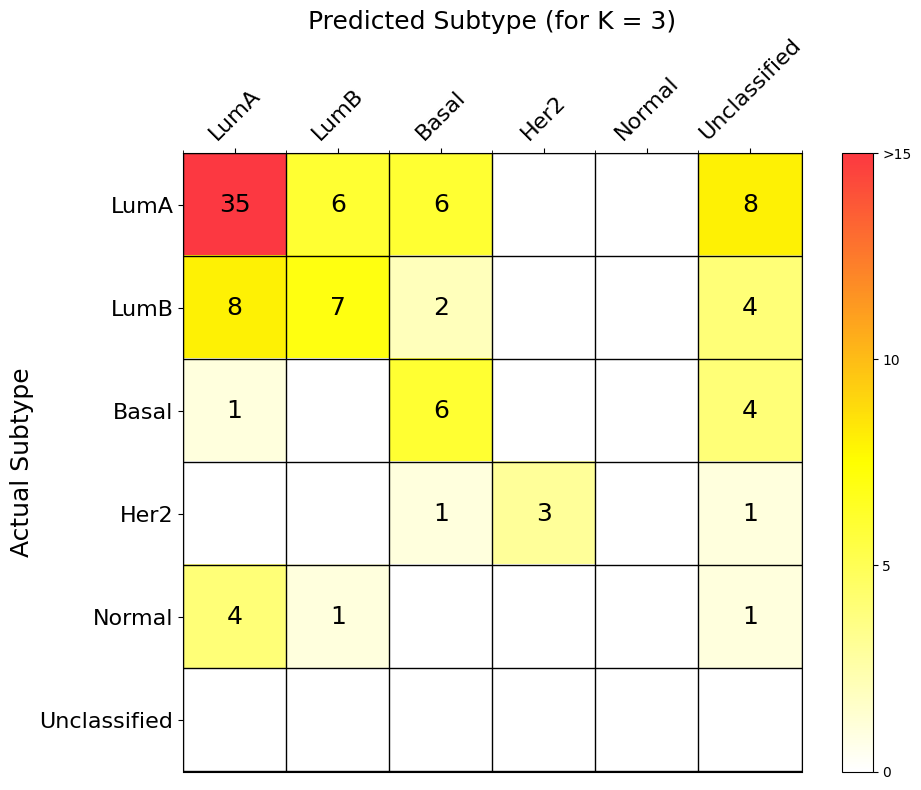

In [ ]:
k = 3

y_true, y_pred = zero_shot_subtype_classification(k)

# 1. Setup labels
classes = ['LumA', 'LumB', 'Basal', 'Her2', 'Normal', 'Unclassified']
assert set(y_true+y_pred+['Unclassified']) == set(classes)

# 2. Generate matrix
cm = confusion_matrix(y_true, y_pred, labels=classes)

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

colors = ["#ffffff", "yellow", "#fc3841"] 
custom_cmap = LinearSegmentedColormap.from_list("white_yellow_red", colors)

mx = 15

# Plot with vmax=10 to keep contrast
disp.plot(
    cmap=custom_cmap, 
    ax=ax, 
    values_format='d', 
    im_kw={'vmax': mx}
)

# 4. INCREASE FONT SIZE of numbers within tiles
# disp.text_ contains the text objects for each cell
for i, text in enumerate(disp.text_.ravel()):
    val = cm.ravel()[i]
    if val == 0:
        text.set_text("")  # Hide the number if it is zero
    else:
        text.set_fontsize(18)
        text.set_color('black')

# 5. ADD BLACK GRID LINES between tiles
# Set minor ticks at the halfway point between labels
ax.set_xticks(np.arange(len(classes) + 1) - 0.5, minor=True)
ax.set_yticks(np.arange(len(classes) + 1) - 0.5, minor=True)
# Draw the grid using those minor ticks
ax.grid(which="minor", color="black", linestyle='-', linewidth=1)
# Hide the minor tick markers themselves
ax.tick_params(which="minor", bottom=False, left=False)

# 6. Adjust Colorbar Legend for ">mx"
cbar = disp.im_.colorbar
new_ticks = list(range(0, mx+1, 5))
cbar.set_ticks(new_ticks)
cbar.set_ticklabels([str(int(t)) if t < mx else '>'+str(mx) for t in new_ticks])

# 7. Final Polish
ax.set_xlabel('Predicted Subtype (for K = '+str(k)+')', fontsize=18)
ax.set_ylabel('Actual Subtype', fontsize=18)
ax.xaxis.set_label_position('top') 
ax.xaxis.tick_top()
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()

plt.savefig("zeroshot_Subtype_Confusion_Matrix.pdf", format='pdf', bbox_inches='tight')

plt.show()

In [943]:
# ------------------------------------------------------------------------------------------------------------------
print("Preprocess gene expression data")

expr = pd.read_csv(os.path.join(PROJECT_DIR, "data", "data_mrna_seq_v2_rsem.txt"), sep="\t")
assert expr.shape[1] == len(set(expr.columns))
genes = expr.iloc[:, :2].copy()
expr = expr.iloc[:, 2:].copy()
expr.columns = [col[:12] for col in expr.columns]
assert expr.notna().all().all()

# extract the columns that are for training data
columns_in_train = list(set(expr.columns) & set(all_data['train_pid']))

# using training data, get the indices of the genes with >10 RSEM in >10% of samples
idx = (100 * (expr[columns_in_train] > 10).sum(axis=1) / len(columns_in_train)) > 10
# to remove lowly expressed genes, subset everything by those indices
genes = genes[idx]
expr = expr[idx]

# log1p-transform all expression data
expr = np.log1p(expr)

# calculate Mean & Standard deviation per gene across the training data
MU = expr[columns_in_train].mean(axis=1)
SD = expr[columns_in_train].std(axis=1)

# get the indices of the top 2000 most variable genes
idx = SD.sort_values(ascending=False).head(2000).index

# subset everything by those indices
genes = genes.loc[idx]
expr = expr.loc[idx]
MU = MU.loc[idx]
SD = SD.loc[idx]

# transform to z-scores using the calculated statistics
assert SD.min() > 1e-8
expr_z = expr.sub(MU, axis=0).div(SD, axis=0)
# make the list of gene identifiers (which is in the same order of rows in the data)
assert not genes['Hugo_Symbol'].astype(str).str.contains("_").any()
assert not genes['Entrez_Gene_Id'].astype(str).str.contains("_").any()
# genes = (genes['Hugo_Symbol'].fillna('Unknown').astype(str) + "_" + genes['Entrez_Gene_Id'].astype(str)).tolist()

# use PCA and preserve the PCs that capture %95 of the variations
pca = PCA(n_components=0.95, whiten=True) # n_components = 0.9 means to keep 90% of variance
# fit the PCA to the training data
pca.fit(expr_z[columns_in_train].T)
# apply the transformation to the whole data
expr_pca = pd.DataFrame(pca.transform(expr_z.T), index=expr_z.columns).T
# ------------------------------------------------------------------------------------------------------------------

Preprocess gene expression data


In [916]:
expr_retr_k10 = pd.DataFrame({
    k: expr[[x for x in v if x in expr.columns][:10]].median(axis=1)
    for k, v in pid_mapping.items() 
    if k in expr.columns
})

expr_retr_k1 = pd.DataFrame({
    k: expr[[x for x in v if x in expr.columns][:1]].median(axis=1)
    for k, v in pid_mapping.items() 
    if k in expr.columns
})

random.seed(456)
expr_retr_rand = pd.DataFrame({
    k: expr[random.sample(all_data['dev_pid'], 10)].median(axis=1)
    for k in pid_mapping.keys() 
    if k in expr.columns
})

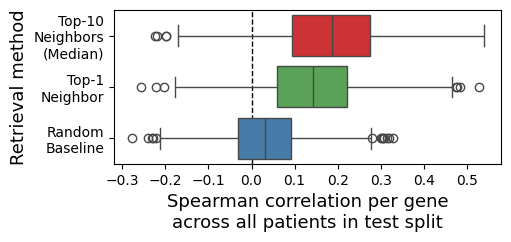

In [ ]:
plt.figure(figsize=(5, 2))
plt.axvline(x=0, color='black', linestyle='--', linewidth=1, zorder=0)
sns.boxplot(data=pd.DataFrame({
    'Top-10\nNeighbors\n(Median)': expr_retr_k10.corrwith(expr[expr_retr_k10.columns], axis=1, method='pearson'),
    'Top-1\nNeighbor': expr_retr_k1.corrwith(expr[expr_retr_k1.columns], axis=1, method='pearson'),
    'Random\nBaseline': expr_retr_rand.corrwith(expr[expr_retr_rand.columns], axis=1, method='pearson')
}), palette=[sns.color_palette("Set1")[i] for i in [0, 2, 1]], orient="h")
plt.xlabel('Spearman correlation per gene\nacross all patients in test split', fontsize=13)
plt.ylabel('Retrieval method', fontsize=13)
plt.savefig('corr.pdf', format='pdf', bbox_inches='tight')
plt.show()

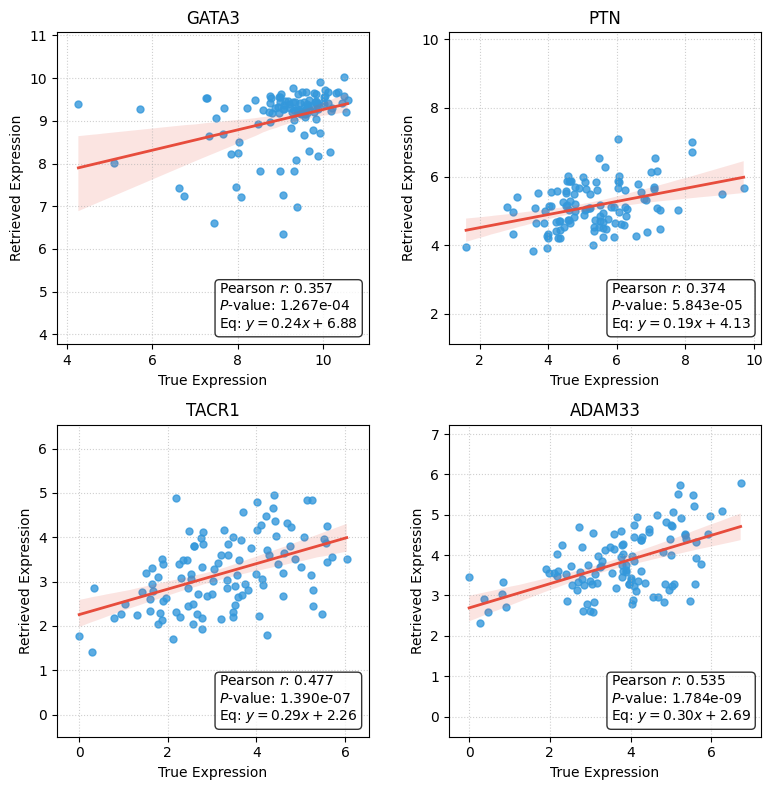

In [ ]:
def sctrplt(g, ax): # Added 'ax' argument

    # True Expression
    x = np.array(expr[expr_retr_k10.columns].loc[genes.loc[genes['Hugo_Symbol'] == g].index]).squeeze()

    # Retrieved Expression
    y = np.array(expr_retr_k10.loc[genes.loc[genes['Hugo_Symbol'] == g].index]).squeeze()

    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    pearson_r, pearson_p = stats.pearsonr(x, y)

    # Tell sns.regplot to use the specific ax
    sns.regplot(x=x, y=y, 
                scatter_kws={'s': 25, 'alpha': 0.8, 'color': '#3498db'}, 
                line_kws={'color': '#e74c3c', 'lw': 2, 'label': 'Best Fit'},
                ci=95, ax=ax)

    all_data = np.concatenate([x, y])
    ax_limit = [all_data.min() - 0.5, all_data.max() + 0.5]
    
    # Use ax.set_ instead of plt.
    ax.set_xlim(ax_limit)
    ax.set_ylim(ax_limit)
    ax.set_aspect('equal', adjustable='box')

    stats_label = (f"Pearson $r$: {pearson_r:.3f}\n"
                   f"$P$-value: {pearson_p:.3e}\n"
                   f"Eq: $y = {slope:.2f}x + {intercept:.2f}$")

    ax.text(0.52, 0.2, stats_label, transform=ax.transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    ax.set_title(g)
    ax.set_xlabel('True Expression')
    ax.set_ylabel('Retrieved Expression')
    ax.grid(True, linestyle=':', alpha=0.6)


fig, axs = plt.subplots(2, 2, figsize=(8, 8))



sctrplt("GATA3", axs[0, 0])
sctrplt("PTN", axs[0, 1])
sctrplt("TACR1", axs[1, 0])
sctrplt("ADAM33", axs[1, 1])


plt.tight_layout()
plt.savefig('expr.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
classes = ['LumA', 'LumB', 'Basal']#, 'Her2', 'Normal']

def clear_missing_data(X1, X2, X3, y, pid, classes):
    rm_indices = [i for i, v in enumerate(y) if v not in classes]
    y = [o for o in y if o in classes]
    X1 = np.delete(X1, rm_indices, axis=0)
    X2 = np.delete(X2, rm_indices, axis=0)
    pid = [pid[i] for i in range(len(pid)) if i not in rm_indices]
    return X1, X2, X3, y, pid

lrData = {
    f'{var}_{k}': val 
    for k in ['dev', 'test'] 
    for var, val in zip(['X1', 'X2', 'X3', 'y', 'pid'], clear_missing_data(
        X1 = all_data[f'{k}_img_emb'].numpy(), 
        X2 = all_data[f'{k}_img'].numpy(), 
        X3 = all_data[f'{k}_expr'].numpy(), 
        y = [pid2subtype.get(p, np.nan) for p in all_data[f'{k}_pid']], 
        pid = all_data[f'{k}_pid'], 
        classes = classes
    ))
}

# sanity check
assert lrData['X1_dev'].shape[0] == len(lrData['y_dev'])
assert lrData['X1_test'].shape[0] == len(lrData['y_test'])
assert lrData['y_dev'] == [pid2subtype[p] for p in lrData['pid_dev']]
assert lrData['y_test'] == [pid2subtype[p] for p in lrData['pid_test']]

In [ ]:
def fitLogReg(X, y):
    stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=8754)
    model = LogisticRegressionCV(
        cv=stratified_cv,  
        solver='saga',      
        l1_ratios=[0.5], 
        max_iter=10000,
        random_state=42,
        use_legacy_attributes=False
    )
    model.fit(X, y)
    return model

In [ ]:
m1 = fitLogReg(lrData['X1_dev'], lrData['y_dev'])

In [716]:
report1 = classification_report(lrData['y_test'], m1.predict(lrData['X1_test']), labels=classes, zero_division=0, output_dict=True)

In [ ]:
preprocessor = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=128))
])
lrData['X2_dev_pca'] = preprocessor.fit_transform(lrData['X2_dev'])
lrData['X2_test_pca'] = preprocessor.transform(lrData['X2_test'])

m2 = fitLogReg(lrData['X2_dev_pca'], lrData['y_dev'])

In [734]:
report2 = classification_report(lrData['y_test'], m2.predict(lrData['X2_test_pca']), labels=classes, zero_division=0, output_dict=True)